In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import sys
sys.path.append("/users/ziyzhang/topology-research")
import globals as gl
plt.rcParams.update({'font.size': 22})
from matplotlib.colors import Normalize

import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable



In [2]:
def plot_bench_bars(_data: dict, legends: list, title: str, x_label: str, y_label: str, y_log: bool = False, normalized: bool = False, errors: dict = None):

    ## Example usage:
    # plot_data = {
    #     'Benchmark 1': [0.8, 0.7, 0.9],  
    #     'Benchmark 2': [0.6, 0.5, 0.7],  
    #     'Benchmark 3': [0.9, 0.8, 0.7],   
    #     'Benchmark 4': [0.9, 0.8, 0.7]
    # }

    # errors_data = {
    #     'Benchmark 1': [(0.05, 0.1), (0.06, 0.12), (0.03, 0.08)],  
    #     'Benchmark 2': [(0.03, 0.08), (0.04, 0.1), (0.02, 0.06)],  
    #     'Benchmark 3': [(0.04, 0.09), (0.05, 0.11), (0.03, 0.07)],   
    #     'Benchmark 4': [(0.03, 0.08), (0.04, 0.1), (0.02, 0.06)]
    # }

    # legends = ['legend 1', 'legend 2', 'legend 3']
    # plot_bench_bars(plot_data, errors_data, legends, "Performance Comparison", "Benchmark", "Performance", y_log=False, normalized=False)

    # Calculate bar width dynamically based on the number of legends
    num_legends = len(legends)
    bar_width = 0.7 / num_legends  # Adjust this scaling factor as needed

    # Generating x positions for each group of bars
    x_positions = np.arange(len(_data))  

    # Generate colors using a predefined colormap
    # colormap = cm.get_cmap('turbo', num_legends)
    colormap =  matplotlib.colormaps['turbo']

    norm = Normalize(vmin=0, vmax=num_legends)  # Normalize values for the colorbar

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 4))  # Adjust size if necessary

    for i, legend in enumerate(legends):
        # Extracting performance metrics for each legend
        performance = [_data[bench][i] for bench in _data]
        if errors:
            error_min_max = np.array([errors[bench][i] for bench in errors])
        
        # Adjusting x positions for each group of bars
        x_positions_adjusted = x_positions + (i - num_legends // 2) * bar_width

        # Scale i to the range of 1 to 100 for the colormap
        shift_i = int((i + 1) / num_legends * 100)

        # Plot bars with color from the colormap
        ax.bar(x_positions_adjusted, performance, width=bar_width, align='center', label=legend, color=colormap(norm(shift_i)))

        # Adding error bars
        if errors:
            error_bars = error_min_max.swapaxes(0, 1)
            ax.errorbar(x_positions_adjusted[:len(errors)], performance[:len(errors)], 
                        error_bars, fmt='none', ecolor='k', capsize=5)

    # Adding labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if y_log:
        ax.set_yscale("log")  
    ax.set_title(title)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(_data.keys())
    ax.set_ylim(0, 11)
    
   # Add a colorbar to represent shift_i from i=1 to i=100
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])  # No data needed for the colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.05)  # Create space for the colorbar

    # Create colorbar
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label('shift_i')
    cbar.set_ticks([1, 107])
    cbar.set_ticklabels(['i = 1', 'i = 107'])

    # Show plot
    plt.show()

In [3]:
df = pd.read_csv("/users/ziyzhang/topology-research/Nexullance_journal_data_gen/MD_Nexullance/DDF/DDF_36_5_MD_IT_uniform_shift_1_halfshift_to_allshifts.csv")

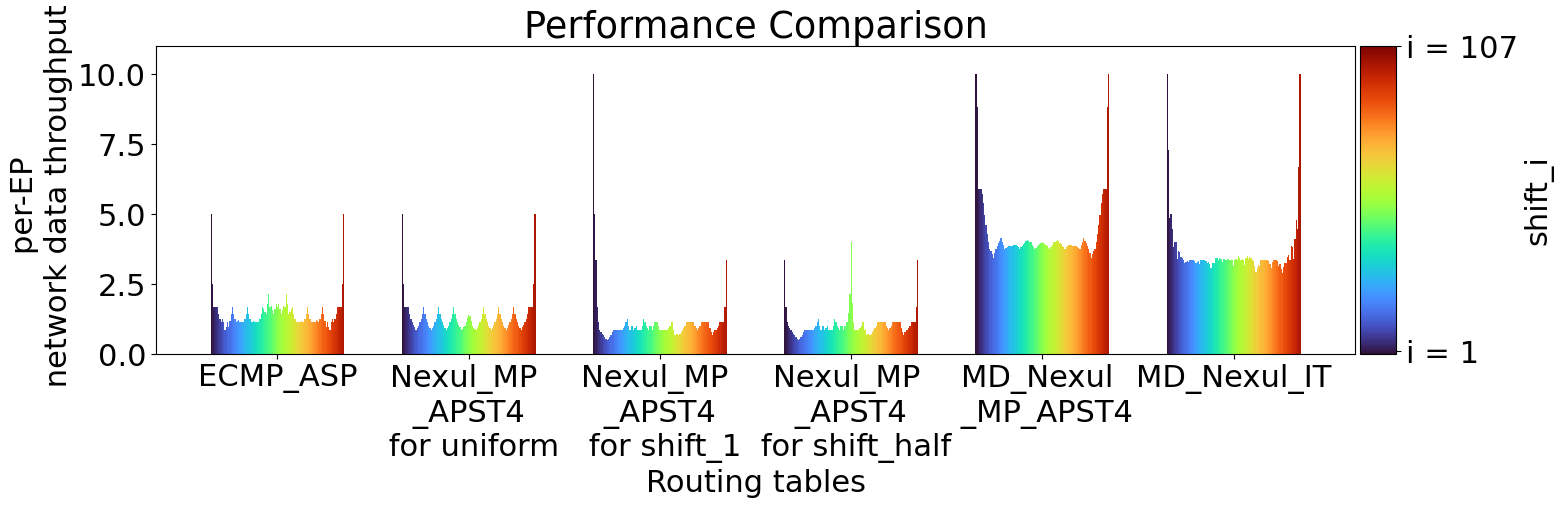

In [4]:
# routing table on the x-axis
plot_data = {
    'ECMP_ASP': list(df["phi_ECMP_ASP"]),  
    'Nexul_MP \n _APST4 \n for uniform': list(df["phi_MP_APST4_uniform"]),  
    'Nexul_MP \n _APST4 \n for shift_1': list(df["phi_MP_APST4_shift_1"]),  
    'Nexul_MP \n _APST4 \n for shift_half': list(df["phi_MP_APST4_halfshift"]),  
    'MD_Nexul \n _MP_APST4': list(df["phi_MD_MP_APST4"]),
    'MD_Nexul_IT': list(df["phi_MD_IT"])
}

legends = list(df["M_name"])
plot_bench_bars(plot_data, legends, "Performance Comparison", "Routing tables", "per-EP \n network data throughput", y_log=False, normalized=False)


In [5]:
# add a new row in df as the harmonic mean

weights = list(df["M_weight"])

harmonic_means = {}
for col in df.columns:
    if df[col].dtype != 'object':  # Exclude non-numeric columns
        harmonic_means[col] = [gl.cal_MD_obj_func(list(df[col]), weights)]

# Convert the harmonic mean dictionary into a new row and append it to the dataframe
harmonic_means['M_name'] = ['harmonic_mean']
harmonic_means['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
harmonic_mean_row = pd.DataFrame(harmonic_means)

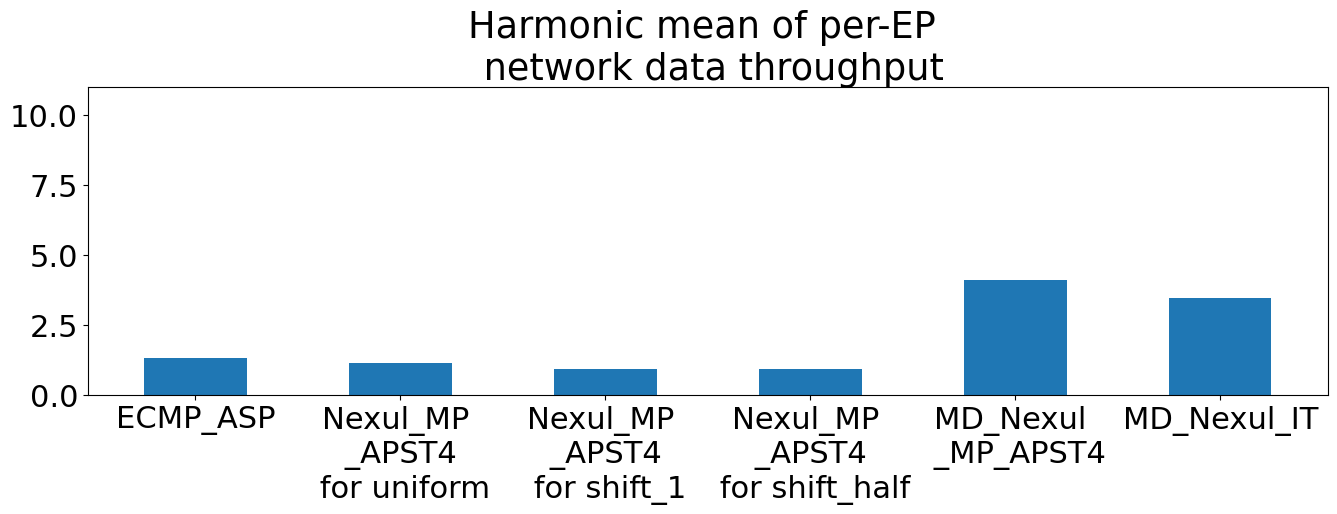

In [12]:
# harmonic mean
# routing table on the x-axis
_data = {
    'ECMP_ASP': list(harmonic_mean_row["phi_ECMP_ASP"])[0],  
    'Nexul_MP \n _APST4 \n for uniform': list(harmonic_mean_row["phi_MP_APST4_uniform"])[0],  
    'Nexul_MP \n _APST4 \n for shift_1': list(harmonic_mean_row["phi_MP_APST4_shift_1"])[0],  
    'Nexul_MP \n _APST4 \n for shift_half': list(harmonic_mean_row["phi_MP_APST4_halfshift"])[0],  
    'MD_Nexul \n _MP_APST4': list(harmonic_mean_row["phi_MD_MP_APST4"])[0],
    'MD_Nexul_IT': list(harmonic_mean_row["phi_MD_IT"])[0]
}

# Generating x positions for each group of bars
x_positions = np.arange(len(_data))  

# Plotting
plt.figure(figsize=(16, 4))  # Adjust size if necessary
# Extracting performance metrics for each legend
performance = [_data[bench] for bench in _data]
# Plotting bars for each legend
plt.bar(x_positions, performance, width=0.5, align='center')

plt.title("Harmonic mean of per-EP \n network data throughput")
plt.xticks(x_positions, _data.keys())
plt.ylim(0, 11)
# Show plot
plt.show()

In [7]:
df = pd.read_csv("/users/ziyzhang/topology-research/Nexullance_journal_data_gen/MD_Nexullance/DDF/DDF_36_5_MD_IT_all_shifts_profiling.csv")

In [8]:
from statistics import mean

df = df[[col for col in df.columns if col.startswith("ave_time_")]]

# add a new row in df as the mean
means = {}
for col in df.columns:
    if df[col].dtype != 'object' and df[col].any():  # Exclude non-numeric columns
        means[col] = mean([ele for ele in df[col] if ele != 0])
# Convert the harmonic mean dictionary into a new row and append it to the dataframe
means['M_name'] = ['mean']
means['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
new_means_row = pd.DataFrame(means)
# add a new row in df as the sum
sums = {}
for col in df.columns:
    if df[col].dtype != 'object':  # Exclude non-numeric columns
        sums[col] = sum(list(df[col]))
# Convert the harmonic mean dictionary into a new row and append it to the dataframe
sums['M_name'] = ['sum']
sums['M_weight'] = [None]  # Keeping M_weight as None since it's not numeric
new_sums_row = pd.DataFrame(sums)

df = pd.concat([df, new_means_row, new_sums_row], axis=0 ,ignore_index=True)

In [9]:
df

,ave_time_MP_APST4,ave_time_IT,ave_time_MD_MP_APST4,ave_time_MD_IT,M_name,M_weight
0,0.418142,0.004546,0.0000,0.000000,NaN,NaN
1,0.428465,0.017718,0.0000,0.000000,NaN,NaN
2,0.380656,0.017703,0.0000,0.000000,NaN,NaN
3,0.388000,0.019791,0.0000,0.000000,NaN,NaN
4,0.391682,0.020321,0.0000,0.000000,NaN,NaN
...,...,...,...,...,...,...
105,0.386931,0.019834,0.0000,0.000000,NaN,NaN
106,0.412455,0.003897,0.0000,0.000000,NaN,NaN
107,0.000000,0.000000,2281.9873,1.011152,NaN,NaN
108,0.405604,0.024798,2281.9873,1.011152,mean,None


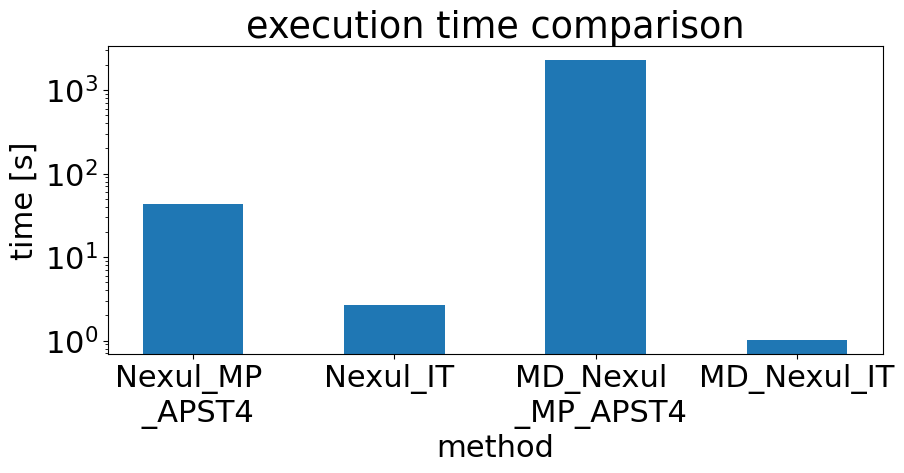

In [10]:
# Sum time
_data = {
    'Nexul_MP \n _APST4': list(df["ave_time_MP_APST4"])[-1],  
    'Nexul_IT \n': list(df["ave_time_IT"])[-1],  
    'MD_Nexul \n _MP_APST4': list(df["ave_time_MD_MP_APST4"])[-1],
    'MD_Nexul_IT': list(df["ave_time_MD_IT"])[-1]
}

# Generating x positions for each group of bars
x_positions = np.arange(len(_data))  

# Plotting
plt.figure(figsize=(10, 4))  # Adjust size if necessary
# Extracting performance metrics for each legend
performance = [_data[bench] for bench in _data]
# Plotting bars for each legend
plt.bar(x_positions, performance, width=0.5, align='center')

# Adding labels and title
plt.xlabel("method")
plt.ylabel("time [s]") 
plt.yscale('log')
plt.title("execution time comparison")
plt.xticks(x_positions, _data.keys())

# Show plot
plt.show()

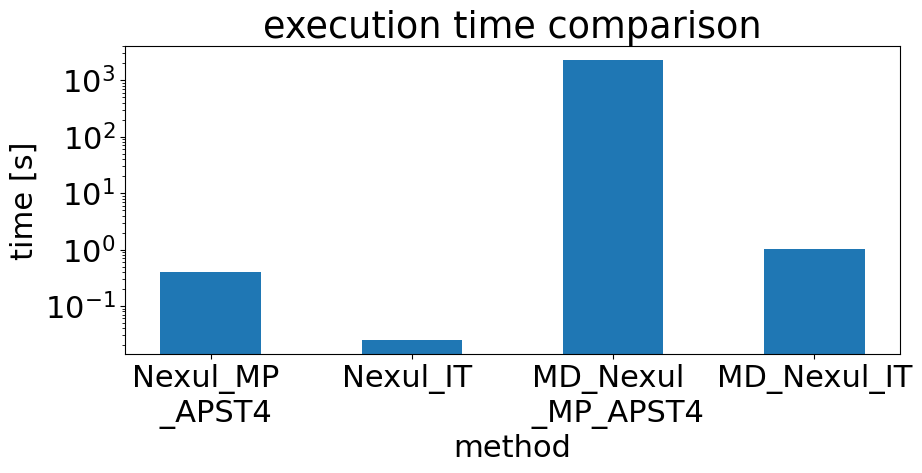

In [11]:
# Mean time
_data = {
    'Nexul_MP \n _APST4': list(df["ave_time_MP_APST4"])[-2],  
    'Nexul_IT \n': list(df["ave_time_IT"])[-2],  
    'MD_Nexul \n _MP_APST4': list(df["ave_time_MD_MP_APST4"])[-2],
    'MD_Nexul_IT': list(df["ave_time_MD_IT"])[-2]
}

# Generating x positions for each group of bars
x_positions = np.arange(len(_data))  

# Plotting
plt.figure(figsize=(10, 4))  # Adjust size if necessary
# Extracting performance metrics for each legend
performance = [_data[bench] for bench in _data]
# Plotting bars for each legend
plt.bar(x_positions, performance, width=0.5, align='center')

# Adding labels and title
plt.xlabel("method")
plt.ylabel("time [s]") 
plt.yscale('log')
plt.title("execution time comparison")
plt.xticks(x_positions, _data.keys())

# Show plot
plt.show()